In [4]:
import warnings
warnings.filterwarnings('ignore')
import io, textwrap, os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import r2_score
import statsmodels.api as sm

OUT_DIR = "infographic_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120


In [10]:
df = pd.read_csv('Family Income and Expenditure.csv')
df.columns = [c.strip() for c in df.columns]

# Convert selected columns to numeric
to_numeric = [c for c in df.columns if c not in ['Region','Main Source of Income','Household Head Sex',
                                                 'Household Head Marital Status','Household Head Highest Grade Completed',
                                                 'Household Head Occupation','Type of Building/House','Type of Roof',
                                                 'Type of Walls','Household Head Job or Business Indicator','Type of Household']]
for col in to_numeric:
    try:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    except Exception:
        pass

df['Has Young Children'] = df['Members with age less than 5 year old'] > 0
df['Has Teens'] = df['Members with age 5 - 17 years old'] > 0
df['Family Size'] = df['Total Number of Family members']
df['Household Head Age Group'] = pd.cut(df['Household Head Age'], bins=[0,24,44,64,200], labels=['<=24','25-44','45-64','65+'])
df['Appliance Count'] = (df.get('Number of Television',0).fillna(0)
                         + df.get('Number of Component/Stereo set',0).fillna(0)
                         + df.get('Number of Refrigerator/Freezer',0).fillna(0)
                         + df.get('Number of Washing Machine',0).fillna(0)
                         + df.get('Number of Airconditioner',0).fillna(0)
                         + df.get('Number of Personal Computer',0).fillna(0))
df['Vehicle Count'] = (df.get('Number of Car, Jeep, Van',0).fillna(0)
                       + df.get('Number of Motorcycle/Tricycle',0).fillna(0)
                       + df.get('Number of Motorized Banca',0).fillna(0))

df['Family Bucket'] = pd.cut(df['Family Size'], bins=[0,2,4,6,100], labels=['1-2','3-4','5-6','7+'])


In [11]:
df.head(12)

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle,Has Young Children,Has Teens,Family Size,Household Head Age Group,Appliance Count,Vehicle Count,Family Bucket
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,0,0,1,False,True,4,45-64,4,1,3-4
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,0,2,False,True,3,25-44,4,2,3-4
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,False,True,6,25-44,0,0,5-6
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,False,True,3,45-64,1,0,3-4
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,0,0,1,False,False,4,65+,2,1,3-4
5,152883,CAR,73326,Wage/Salaries,0,29065,25190,15336,8572,2614,...,0,0,1,False,False,4,45-64,2,1,3-4
6,198621,CAR,104644,Wage/Salaries,0,40992,36312,12968,12310,2565,...,0,0,1,True,False,5,45-64,2,1,5-6
7,134961,CAR,95644,Other sources of Income,1,37168,28156,14640,15896,3365,...,0,0,1,True,True,5,25-44,2,1,5-6
8,171152,CAR,67348,Other sources of Income,0,23117,15845,11464,6685,1370,...,0,0,0,False,True,2,<=24,1,0,1-2
9,625753,CAR,158721,Enterpreneurial Activities,0,56003,43239,26488,25678,3880,...,0,0,0,False,False,6,45-64,4,1,5-6


In [12]:
#df.info()

In [13]:
quantiles = df['Total Household Income'].quantile([0.4, 0.6, 0.8, 0.9])

print("Income Quantile Thresholds")
print(quantiles)

region_median_income = df.groupby('Region')['Total Household Income'].median().sort_values(ascending=False).reset_index()

print("\nMedian Household Income by Region")
print(region_median_income)

region_median_income.to_csv('median_income_by_region.csv', index=False)

Income Quantile Thresholds
0.4    137335.2
0.6    200730.8
0.8    338027.4
0.9    502021.0
Name: Total Household Income, dtype: float64

Median Household Income by Region
                       Region  Total Household Income
0                         NCR                312275.0
1            IVA - CALABARZON                227757.0
2         III - Central Luzon                220208.0
3                         CAR                188580.0
4           I - Ilocos Region                172109.5
5         II - Cagayan Valley                167560.0
6           XI - Davao Region                159647.0
7       VII - Central Visayas                155566.0
8        VI - Western Visayas                147370.0
9              IVB - MIMAROPA                140483.0
10           V - Bicol Region                134571.0
11                     Caraga                132282.5
12      X - Northern Mindanao                131806.0
13  IX - Zasmboanga Peninsula                126567.0
14     VIII - Easte

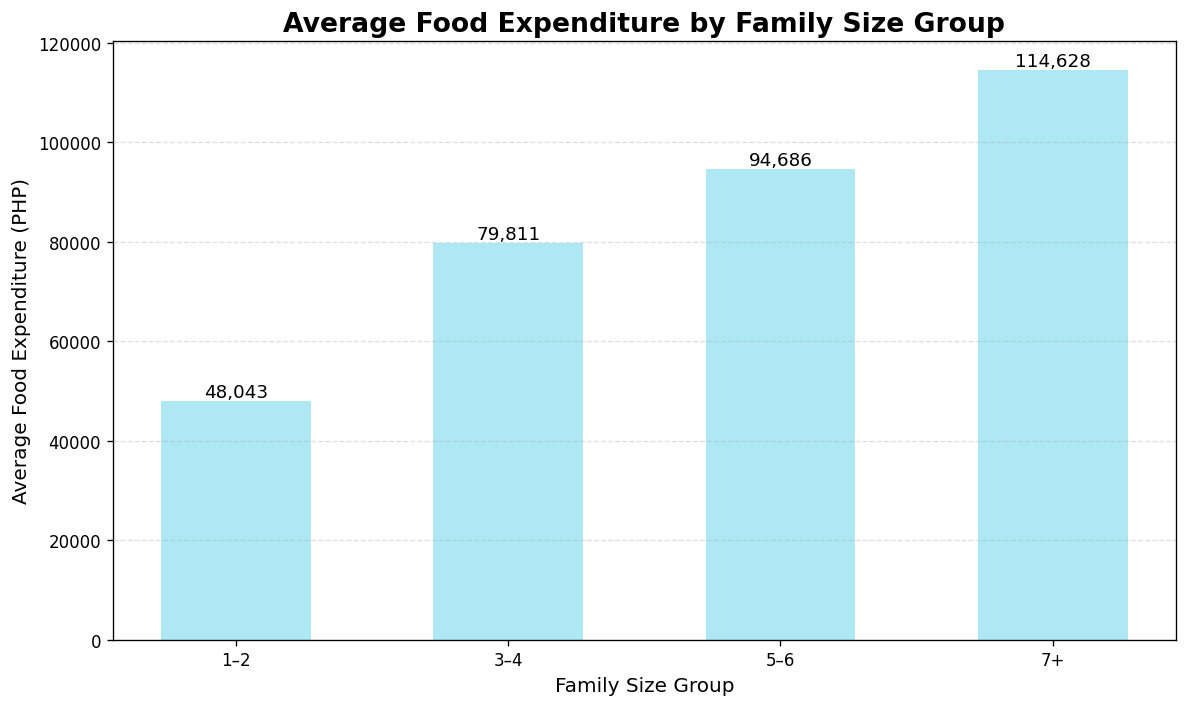

In [14]:
df['Family Size Group'] = pd.cut(
    df['Total Number of Family members'],
    bins=[0, 2, 4, 6, 20],
    labels=['1–2', '3–4', '5–6', '7+'],
    include_lowest=True
)

grouped = df.groupby('Family Size Group')['Total Food Expenditure'].mean().reset_index()
plt.figure(figsize=(10, 6))

bars = plt.bar(
    grouped['Family Size Group'], 
    grouped['Total Food Expenditure'],
    width=0.55,
    color = '#ADE8F4'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha='center', va='bottom', fontsize=11
    )

plt.title("Average Food Expenditure by Family Size Group", fontsize=16, fontweight='bold')
plt.xlabel("Family Size Group", fontsize=12)
plt.ylabel("Average Food Expenditure (PHP)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
#plt.savefig(f"{OUT_DIR}/average_food_expenditure_byFamilysize.png", bbox_inches='tight')
plt.show()


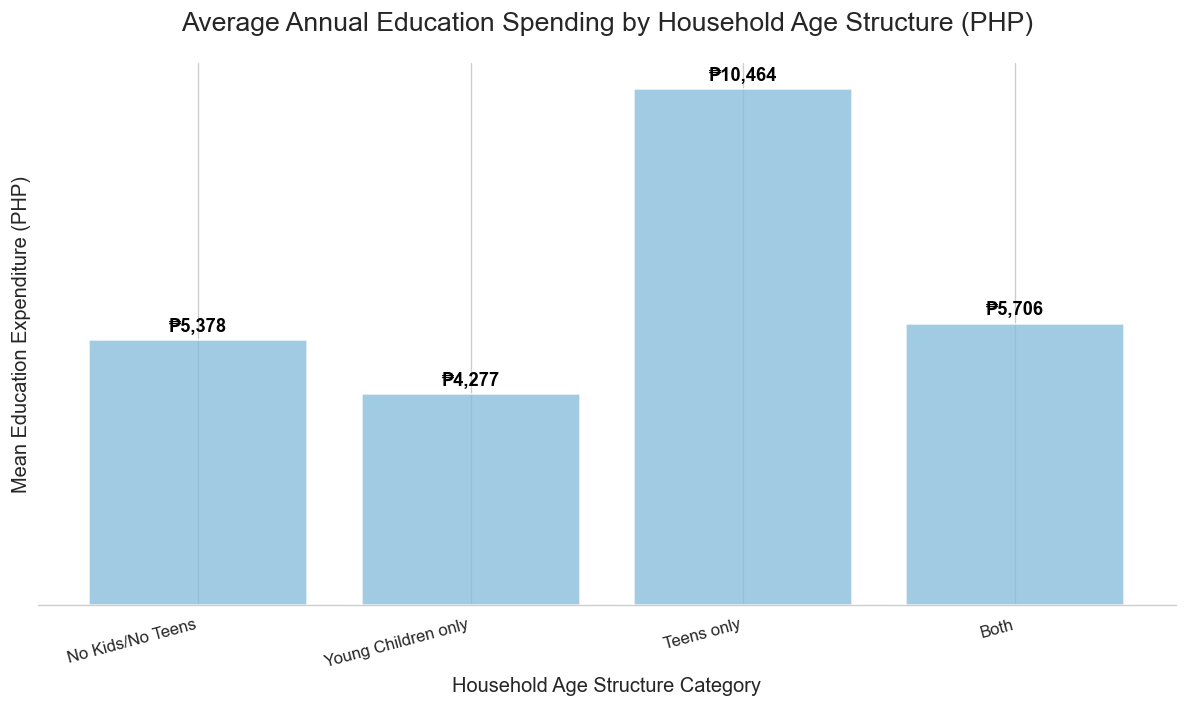

In [6]:
df['Has Young Children'] = df['Members with age less than 5 year old'] > 0
df['Has Teens'] = df['Members with age 5 - 17 years old'] > 0

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

labels = ['No Kids/No Teens', 'Young Children only', 'Teens only', 'Both']
vals = [
    df[(df['Has Young Children']==False) & (df['Has Teens']==False)]['Education Expenditure'].mean(),
    df[(df['Has Young Children']==True) & (df['Has Teens']==False)]['Education Expenditure'].mean(),
    df[(df['Has Young Children']==False) & (df['Has Teens']==True)]['Education Expenditure'].mean(),
    df[(df['Has Young Children']==True) & (df['Has Teens']==True)]['Education Expenditure'].mean()
]
vals = [0 if pd.isna(v) else v for v in vals]

xlocs = np.arange(len(labels))

bar_color = sns.color_palette("Blues")[2] 
bars = plt.bar(xlocs, vals, color=bar_color, alpha=0.8)

plt.title("Average Annual Education Spending by Household Age Structure (PHP)", fontsize=16, pad=20)
plt.ylabel("Mean Education Expenditure (PHP)", fontsize=12)
plt.xlabel("Household Age Structure Category", fontsize=12)

plt.xticks(xlocs, labels, rotation=15, ha='right', fontsize=10)

max_val = max(vals)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + max_val * 0.01, 
             f"₱{yval:,.0f}", ha='center', va='bottom', fontsize=11, 
             fontweight='bold', color='black')

sns.despine(left=True)

plt.yticks([]) 
plt.tight_layout()
#plt.savefig(f"{OUT_DIR}/family_vs_food.png", bbox_inches='tight')
plt.show()

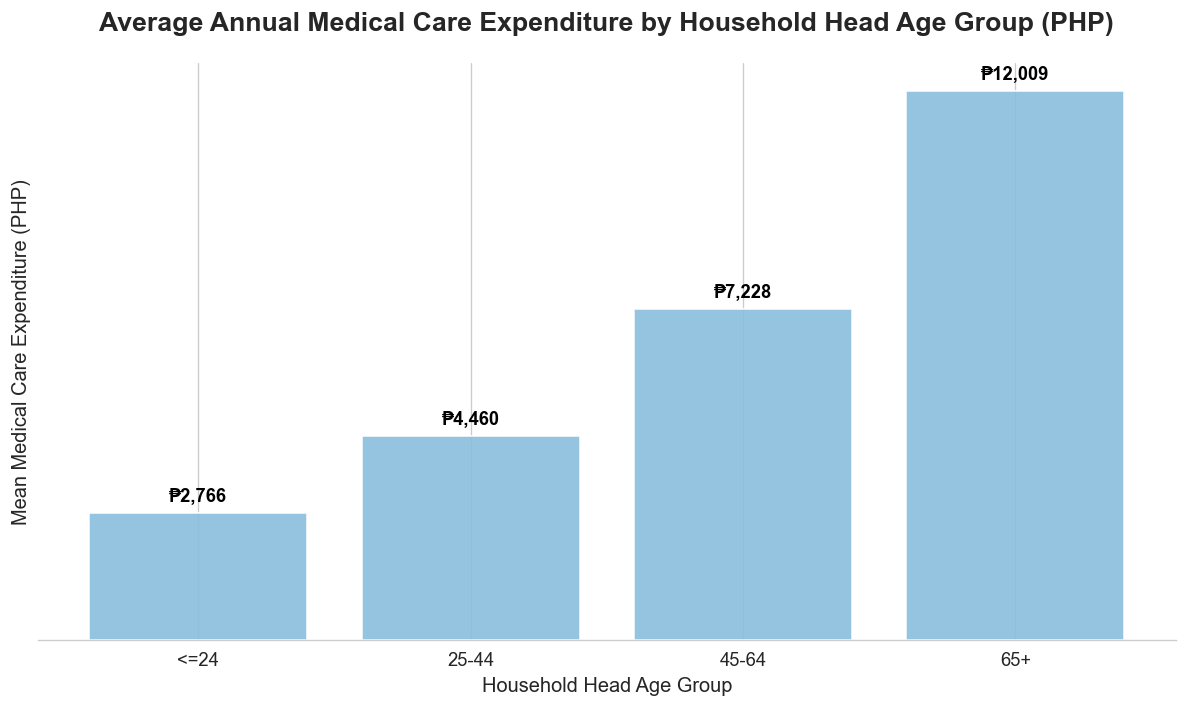

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

age_groups = df.groupby('Household Head Age Group')['Medical Care Expenditure'].mean().reindex(['<=24','25-44','45-64','65+']).fillna(0)
vals = age_groups.values
labels = age_groups.index.astype(str)


bar_color = sns.color_palette("Blues")[2] 
bars = plt.bar(labels, vals, color=bar_color, alpha=0.9)

plt.title("Average Annual Medical Care Expenditure by Household Head Age Group (PHP)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Mean Medical Care Expenditure (PHP)", fontsize=12)
plt.xlabel("Household Head Age Group", fontsize=12)

plt.xticks(fontsize=11)

max_val = max(vals) if len(vals) > 0 else 0
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + max_val * 0.015, 
             f"₱{yval:,.0f}", ha='center', va='bottom', fontsize=11, 
             fontweight='semibold', color='black')

sns.despine(left=True)

plt.yticks([]) 
plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/medical_by_head_age.png", bbox_inches='tight')
plt.show()

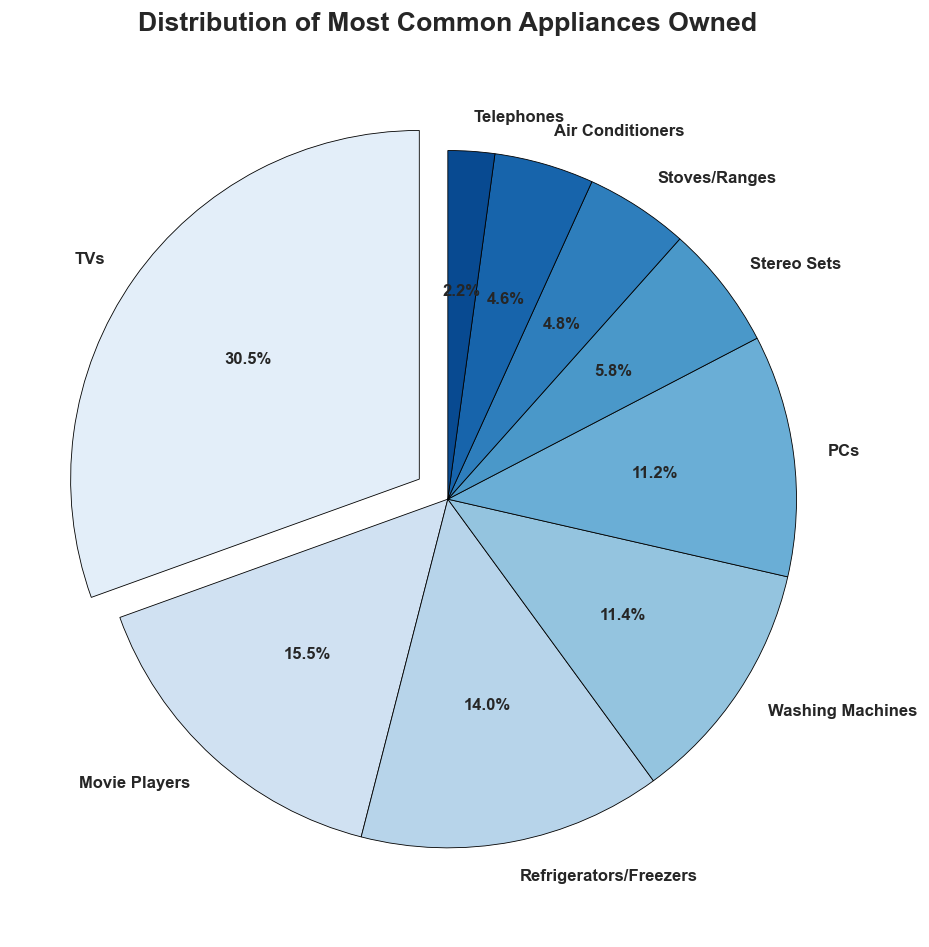

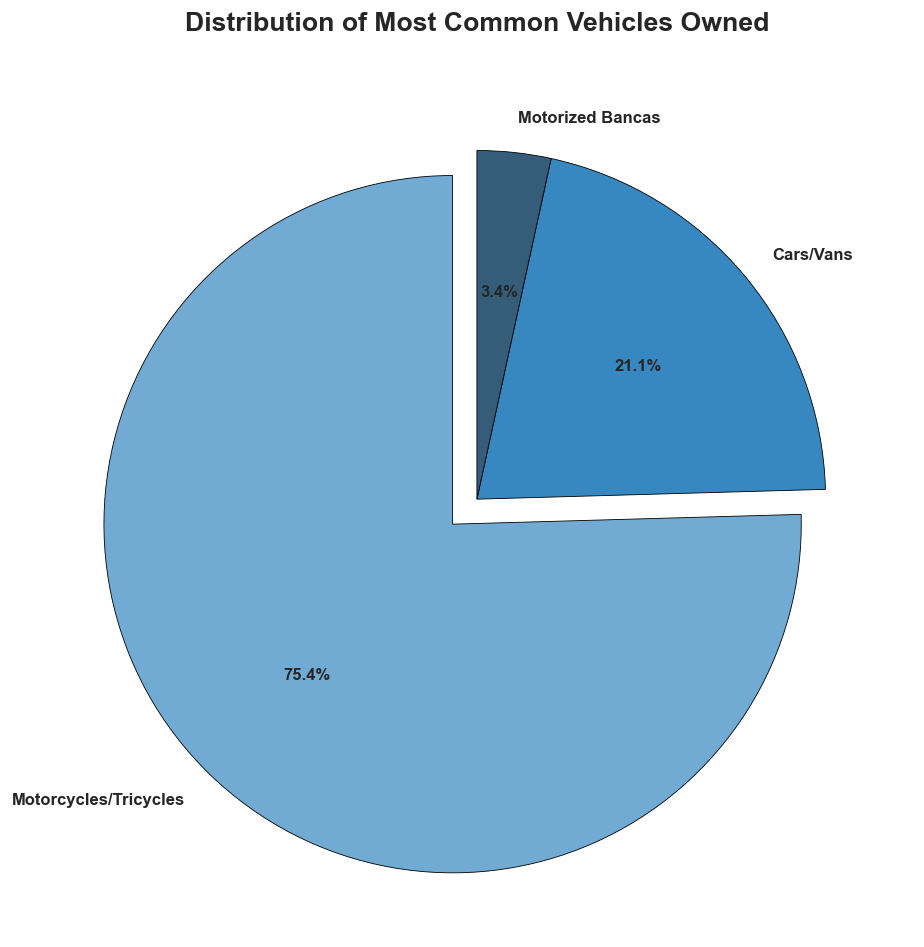

In [8]:
APPLIANCE_COLS = [
    'Number of Television', 
    'Number of CD/VCD/DVD',
    'Number of Refrigerator/Freezer', 
    'Number of Landline/wireless telephones',
    'Number of Washing Machine', 
    'Number of Airconditioner', 
    'Number of Component/Stereo set', 
    'Number of Personal Computer', 
    'Number of Stove with Oven/Gas Range'
]

VEHICLE_COLS = [
    'Number of Car, Jeep, Van', 
    'Number of Motorcycle/Tricycle', 
    'Number of Motorized Banca'
]


appliances_data = {}
appliance_labels_map = {
    'Number of Television': 'TVs', 
    'Number of CD/VCD/DVD' : 'Movie Players',
    'Number of Refrigerator/Freezer': 'Refrigerators/Freezers', 
    'Number of Landline/wireless telephones' : 'Telephones',
    'Number of Washing Machine': 'Washing Machines', 
    'Number of Airconditioner': 'Air Conditioners', 
    'Number of Component/Stereo set': 'Stereo Sets', 
    'Number of Personal Computer': 'PCs', 
    'Number of Stove with Oven/Gas Range': 'Stoves/Ranges'
}

for col, label in appliance_labels_map.items():
    if col in df.columns:
        appliances_data[label] = df[col].sum()

vehicles_data = {}
vehicle_labels_map = {
    'Number of Car, Jeep, Van': 'Cars/Vans', 
    'Number of Motorcycle/Tricycle': 'Motorcycles/Tricycles', 
    'Number of Motorized Banca': 'Motorized Bancas'
}

for col, label in vehicle_labels_map.items():
    if col in df.columns:
        vehicles_data[label] = df[col].sum()


plt.figure(figsize=(8, 8))

appliances_series = pd.Series(appliances_data).sort_values(ascending=False)
labels_appl = appliances_series.index
values_appl = appliances_series.values

colors_appl = sns.color_palette("Blues", len(labels_appl))
explode_appl = [0.1 if i == values_appl.argmax() else 0 for i in range(len(values_appl))]

plt.pie(values_appl, 
        labels=labels_appl, 
        autopct='%1.1f%%', 
        startangle=90, 
        explode=explode_appl, 
        colors=colors_appl,
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
        textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title("Distribution of Most Common Appliances Owned", fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/appliances_pie_chart.png", bbox_inches='tight') # Uncomment if needed
plt.show()

plt.figure(figsize=(8, 8))

vehicles_series = pd.Series(vehicles_data).sort_values(ascending=False)
labels_veh = vehicles_series.index
values_veh = vehicles_series.values

colors_veh = sns.color_palette("Blues_d", len(labels_veh))
explode_veh = [0.1 if i == values_veh.argmax() else 0 for i in range(len(values_veh))]

plt.pie(values_veh, 
        labels=labels_veh, 
        autopct='%1.1f%%', 
        startangle=90, 
        explode=explode_veh, 
        colors=colors_veh,
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
        textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title("Distribution of Most Common Vehicles Owned", fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
#plt.savefig(f"{OUT_DIR}/vehicles_pie_chart.png", bbox_inches='tight')
plt.show()

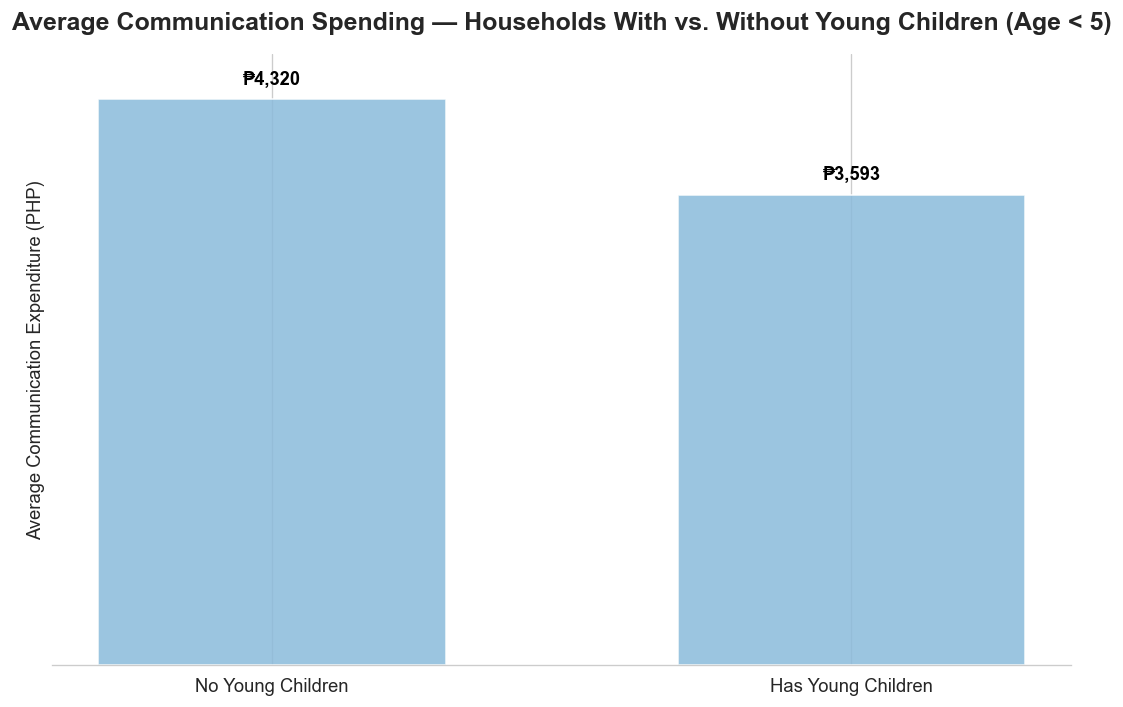

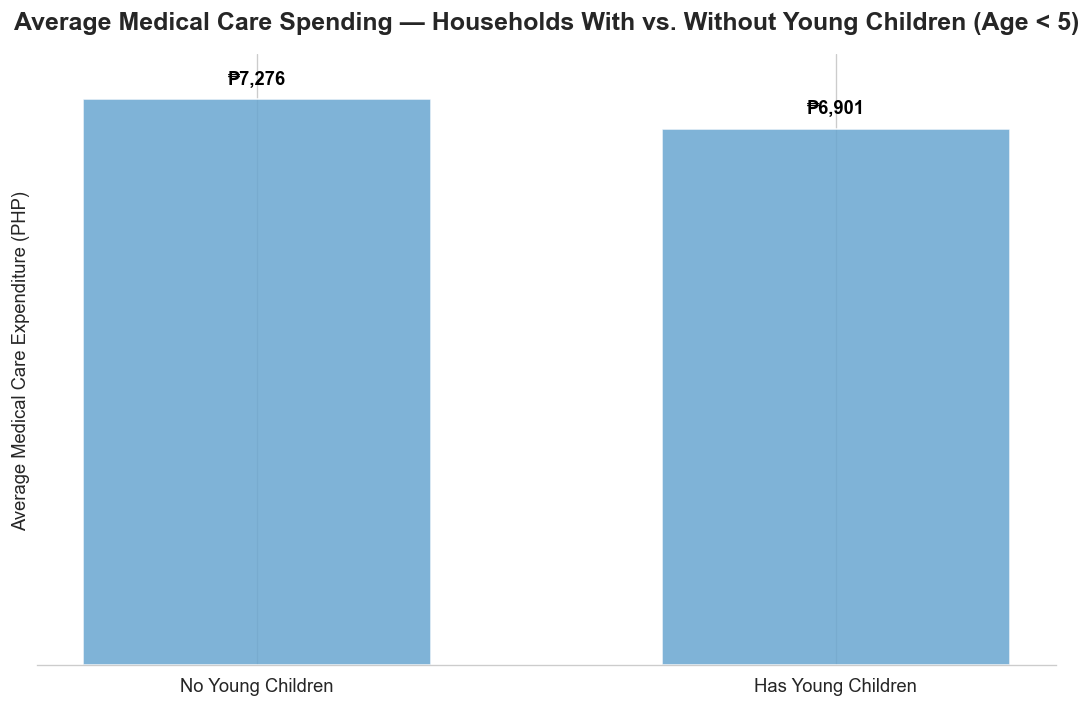

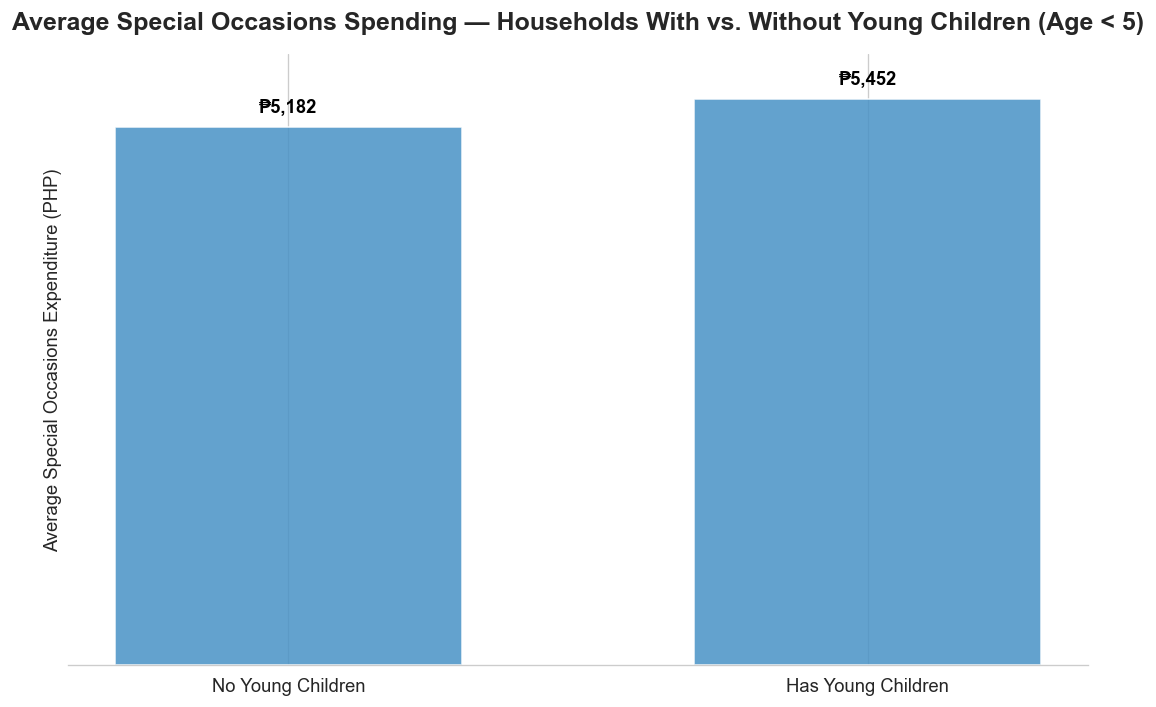

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

columns_to_analyze = ['Communication Expenditure', 'Medical Care Expenditure', 'Special Occasions Expenditure']
titles = {
    'Communication Expenditure': 'Average Communication Spending',
    'Medical Care Expenditure': 'Average Medical Care Spending',
    'Special Occasions Expenditure': 'Average Special Occasions Spending'
}

palette = sns.color_palette("Blues_d") 

for idx, col in enumerate(columns_to_analyze):
    plt.figure(figsize=(9, 6))

    means = df.groupby('Has Young Children')[col].mean().reindex([False, True]).fillna(0)
    vals = means.values
    labels = ['No Young Children', 'Has Young Children']

    bar_color = palette[idx] 
    bars = plt.bar(labels, vals, color=bar_color, alpha=0.85, width=0.6)

    plt.title(f"{titles[col]} — Households With vs. Without Young Children (Age < 5)", 
              fontsize=15, pad=15, fontweight='bold')
    plt.ylabel(f"Average {col} (PHP)", fontsize=11)
    
    plt.xticks(fontsize=11)

    max_val = max(vals) if len(vals) > 0 else 0
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + max_val * 0.02, 
                 f"₱{yval:,.0f}", ha='center', va='bottom', fontsize=11, 
                 fontweight='semibold', color='black')

    sns.despine(left=True)
    plt.yticks([]) 
    
    plt.ylim(0, max_val * 1.08)

    plt.tight_layout()
    
    safe_name = col.lower().replace(' ','_').replace('/','_')
    #plt.savefig(f"{OUT_DIR}/_{safe_name}_young_children.png", bbox_inches='tight')
    plt.show()

Correlation Matrix Table


,Family Size,Income,Food Exp.,Education Exp.,Medical Exp.,Appliances,Vehicles,Employed Members
Family Size,1.000000,0.150000,0.420000,0.090000,0.000000,0.040000,0.100000,0.410000
Income,0.150000,1.000000,0.660000,0.440000,0.300000,0.670000,0.450000,0.210000
Food Exp.,0.420000,0.660000,1.000000,0.370000,0.190000,0.610000,0.370000,0.340000
Education Exp.,0.090000,0.440000,0.370000,1.000000,0.090000,0.390000,0.230000,0.040000
Medical Exp.,0.000000,0.300000,0.190000,0.090000,1.000000,0.240000,0.130000,0.020000
Appliances,0.040000,0.670000,0.610000,0.390000,0.240000,1.000000,0.490000,0.110000
Vehicles,0.100000,0.450000,0.370000,0.230000,0.130000,0.490000,1.000000,0.090000
Employed Members,0.410000,0.210000,0.340000,0.040000,0.020000,0.110000,0.090000,1.000000


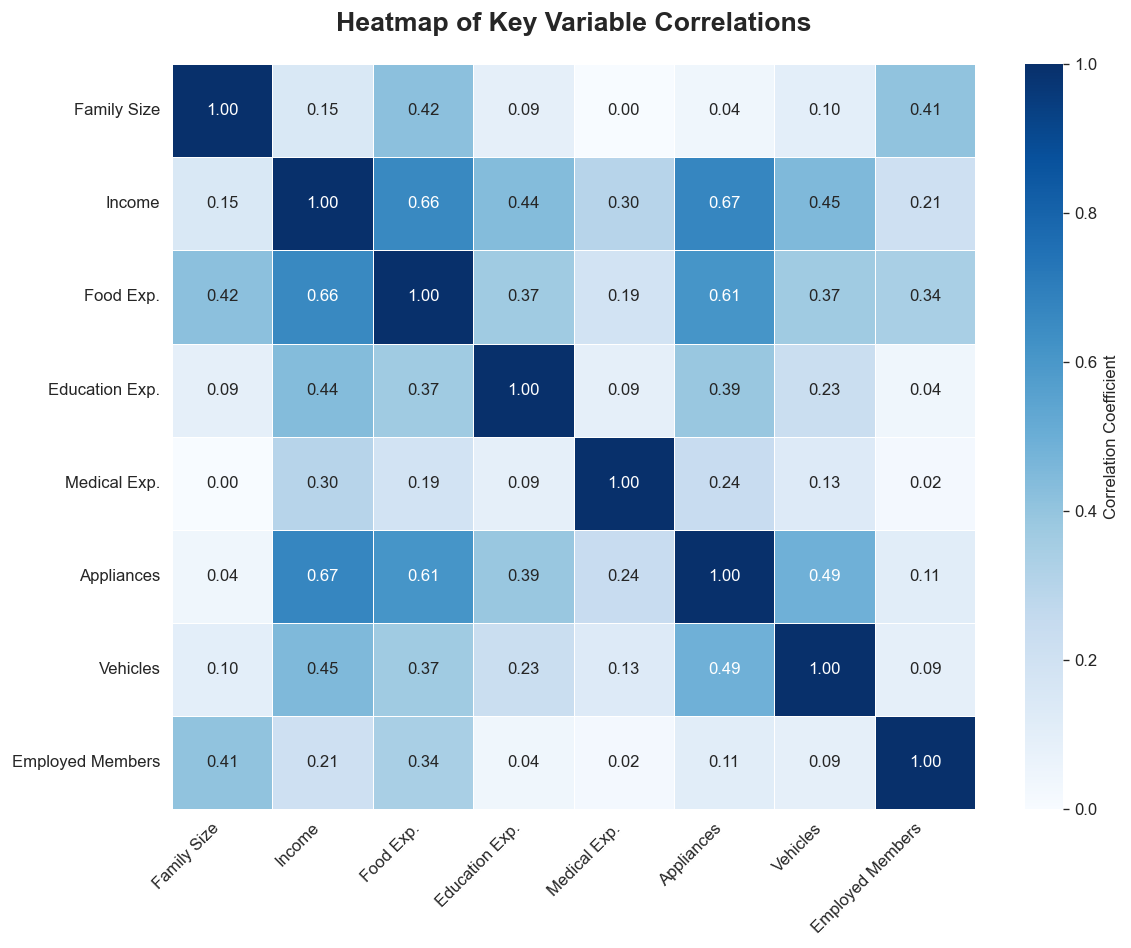

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_interest = df[['Total Number of Family members', 
                       'Total Household Income', 
                       'Total Food Expenditure', 
                       'Education Expenditure', 
                       'Medical Care Expenditure', 
                       'Appliance Count', 
                       'Vehicle Count', 
                       'Total number of family members employed']].copy()

numeric_interest.columns = ['Family Size', 'Income', 'Food Exp.', 
                            'Education Exp.', 'Medical Exp.', 
                            'Appliances', 'Vehicles', 'Employed Members']

corr = numeric_interest.corr().round(2)

print("Correlation Matrix Table")
display(corr.style.background_gradient(cmap='coolwarm', axis=None)
                 .set_properties(**{'font-size': '10pt'})
                 .set_caption("Pearson Correlation Coefficients"))


plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=True, 
    cmap='Blues',
    fmt=".2f",     
    linewidths=.5,  
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Heatmap of Key Variable Correlations', fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
#plt.savefig(f"{OUT_DIR}/heatmap.png", bbox_inches='tight')
plt.show()

In [18]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('_,', '_').str.replace('-', '_').str.replace(r'[\(\)\.,]', '', regex=True).str.replace('/', '_')

#filter for income > 0 and clean/transform necessary columns
df_clean = df[df['Total_Household_Income'] > 0].copy()

df_clean['Total_Income_from_Entrepreneurial_Acitivites'] = pd.to_numeric(
    df_clean['Total_Income_from_Entrepreneurial_Acitivites'], errors='coerce'
).fillna(0)

df_clean['Total_Number_of_Family_members'] = pd.to_numeric(
    df_clean['Total_Number_of_Family_members'], errors='coerce'
).fillna(0)

df_clean['log_Total_Household_Income'] = np.log1p(df_clean['Total_Household_Income'])

df_clean['log_Total_Number_of_Family_members'] = np.log1p(
    df_clean['Total_Number_of_Family_members']
)
df_clean['log_Total_Income_from_Entrepreneurial_Acitivites'] = np.log1p(
    df_clean['Total_Income_from_Entrepreneurial_Acitivites']
)

target = df_clean['log_Total_Household_Income']
predictors = [
    'log_Total_Number_of_Family_members',
    'log_Total_Income_from_Entrepreneurial_Acitivites',
    'Household_Head_Highest_Grade_Completed'
]

X = df_clean[predictors].copy()
y = target

X = pd.get_dummies(
    X,
    columns=['Household_Head_Highest_Grade_Completed'],
    drop_first=True,
    dtype=float
)

X = sm.add_constant(X)

X = X.astype(float)
y = y.astype(float)

valid = X.notna().all(axis=1) & y.notna()
X = X[valid]
y = y[valid]

#fit model
model = sm.OLS(y, X).fit()

r_squared = model.rsquared

#get the coefficient for entrepreneurial income
entrepreneurial_income_coeff = model.params.loc['log_Total_Income_from_Entrepreneurial_Acitivites']
entrepreneurial_income_pvalue = model.pvalues.loc['log_Total_Income_from_Entrepreneurial_Acitivites']

#find the highest education coefficient (highest positive impact on income)
education_coeffs = model.params.filter(regex='^Household_Head_Highest_Grade_Completed_')
education_pvalues = model.pvalues.filter(regex='^Household_Head_Highest_Grade_Completed_')

education_results = pd.DataFrame({
    'Coefficient': education_coeffs,
    'P-value': education_pvalues
})
significant_education_impact = education_results[education_results['P-value'] < 0.05]
highest_positive_impact_name = significant_education_impact['Coefficient'].idxmax()
highest_positive_coeff = significant_education_impact['Coefficient'].max()


print("Predictive Modeling Results (Total Household Income)")
print(f"Model R-squared: {r_squared:.3f}")
print(f"Entrepreneurial Income Coefficient (Elasticity): {entrepreneurial_income_coeff:.3f} (P-value: {entrepreneurial_income_pvalue:.3f})")
print(f"Highest Education Level Impact: {highest_positive_impact_name} (Coefficient: {highest_positive_coeff:.3f})")

Predictive Modeling Results (Total Household Income)
Model R-squared: 0.389
Entrepreneurial Income Coefficient (Elasticity): 0.004 (P-value: 0.000)
Highest Education Level Impact: Household_Head_Highest_Grade_Completed_Law Programs (Coefficient: 0.958)


In [19]:
df = pd.read_csv('Family Income and Expenditure.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('_,', '_').str.replace('-', '_').str.replace(r'[\(\)\.,]', '', regex=True).str.replace('/', '_')
df_clean = df[df['Total_Household_Income'] > 0].copy()
df_clean['log_Total_Household_Income'] = np.log1p(df_clean['Total_Household_Income'])

asset_cols = [
    'Number_of_Television',
    'Number_of_CD_VCD_DVD',
    'Number_of_Component_Stereo_set',
    'Number_of_Refrigerator_Freezer',
    'Number_of_Washing_Machine',
    'Number_of_Airconditioner',
    'Number_of_Car_Jeep_Van',
    'Number_of_Landline_wireless_telephones',
    'Number_of_Cellular_phone',
    'Number_of_Personal_Computer',
    'Number_of_Stove_with_Oven_Gas_Range',
    'Number_of_Motorized_Banca',
    'Number_of_Motorcycle_Tricycle'
]

for col in asset_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# Create the new continuous target: Total Electronic Assets
df_clean['Total_Electronic_Assets'] = df_clean[asset_cols].sum(axis=1)
df_clean['log_Total_Electronic_Assets'] = np.log1p(df_clean['Total_Electronic_Assets'])

# Predictor 2: House_Floor_Area
df_clean['House_Floor_Area'] = pd.to_numeric(
    df_clean['House_Floor_Area'], errors='coerce'
).fillna(0)
df_clean['log_House_Floor_Area'] = np.log1p(df_clean['House_Floor_Area'])

# Select the target and predictors
target_5 = df_clean['log_Total_Electronic_Assets']
predictors_5 = [
    'log_Total_Household_Income',
    'log_House_Floor_Area',
    'Tenure_Status'
]

X_5 = df_clean[predictors_5].copy()
y_5 = target_5

# Handle categorical variable (Tenure Status)
X_5 = pd.get_dummies(X_5, columns=['Tenure_Status'], drop_first=True)

X_5 = sm.add_constant(X_5)

X_5 = X_5.dropna()
y_5 = y_5[X_5.index]

X_5 = X_5.apply(pd.to_numeric, errors='coerce')
y_5 = pd.to_numeric(y_5, errors='coerce')

valid = X_5.notnull().all(axis=1) & y_5.notnull()
X_5 = X_5[valid]
y_5 = y_5[valid]

# convert data type for numpy
X_5 = X_5.astype(float)
y_5 = y_5.astype(float)


# Fit the Multiple Linear Regression model
model_5 = sm.OLS(y_5, X_5).fit()

r_squared_5 = model_5.rsquared

#income coefficient
income_coeff = model_5.params['log_Total_Household_Income']
income_pvalue = model_5.pvalues['log_Total_Household_Income']

#find the highest tenure status coefficient (highest predicted asset ownership)
tenure_coeffs = model_5.params.filter(regex='^Tenure_Status_')
tenure_pvalues = model_5.pvalues.filter(regex='^Tenure_Status_')

tenure_results = pd.DataFrame({
    'Coefficient': tenure_coeffs,
    'P-value': tenure_pvalues
})
significant_tenure_impact = tenure_results[tenure_results['P-value'] < 0.05]

#find the highest positive coefficient (highest predicted asset boost)
highest_positive_impact_name = significant_tenure_impact['Coefficient'].idxmax()
highest_positive_coeff = significant_tenure_impact['Coefficient'].max()


print("\nPredictive Modeling Results (Total Electronic Assets)\n")
print(f"Model R-squared: {r_squared_5:.3f}")
print(f"Log Income Coefficient (Elasticity): {income_coeff:.3f} (P-value: {income_pvalue:.3f})")
print(f"Highest Tenure Status Impact: {highest_positive_impact_name} (Coefficient: {highest_positive_coeff:.3f})")


Predictive Modeling Results (Total Electronic Assets)

Model R-squared: 0.606
Log Income Coefficient (Elasticity): 0.706 (P-value: 0.000)
Highest Tenure Status Impact: Tenure_Status_Rent house/room including lot (Coefficient: 0.227)


In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("Family Income and Expenditure.csv")

df.columns = (
    df.columns.str.strip()
    .str.replace(' ', '_')
    .str.replace('_,', '_')
    .str.replace('-', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('.', '')
    .str.replace('/', '_')
)

df_clean = df[df['Total_Household_Income'] > 0].copy()

df_clean['Food_Exp_Ratio'] = (
    df_clean['Total_Food_Expenditure'] /
    df_clean['Total_Household_Income']
)

#identify high strain
threshold = df_clean['Food_Exp_Ratio'].quantile(0.95)
df_clean['Is_High_Strain'] = (df_clean['Food_Exp_Ratio'] > threshold).astype(int)

print("-" * 40)
print(f"Total Households: {len(df_clean)}")
print(f"High Strain Threshold: {threshold:.4f}")
print(f"High Strain Households: {df_clean['Is_High_Strain'].sum()} "
      f"({df_clean['Is_High_Strain'].mean()*100:.2f}%)")

predictors = [
    'Total_Number_of_Family_members',
    'Agricultural_Household_indicator',
    'Region',
    'Household_Head_Highest_Grade_Completed'
]

X = df_clean[predictors].copy()
y = df_clean['Is_High_Strain'].copy()

#oone-hot encode categorical predictors
X = pd.get_dummies(
    X,
    columns=['Region', 'Household_Head_Highest_Grade_Completed'],
    drop_first=True,
    dtype=float
)

X = X.astype(float)
y = y.astype(int)  

X = sm.add_constant(X)

#drop any NA rows
valid = X.notna().all(axis=1) & y.notna()
X = X[valid]
y = y[valid]

#confirm y is binary
print("Unique y values:", y.unique())

#run logistic regression
model = sm.Logit(y, X).fit()

#extract odds ratios
results = np.exp(model.conf_int())
results['Odds Ratio'] = np.exp(model.params)
results['P-value'] = model.pvalues
results = results.rename(columns={0: 'Lower CI', 1: 'Upper CI'})

significant = results[results['P-value'] < 0.05].drop('const', errors='ignore')
significant = significant.sort_values(by='Odds Ratio', ascending=False)

print("\nSignificant Factors (Odds Ratios):")
print(significant[['Odds Ratio', 'P-value']].to_markdown(floatfmt=".2f"))


----------------------------------------
Total Households: 41544
High Strain Threshold: 0.7453
High Strain Households: 2078 (5.00%)
Unique y values: [0 1]
         Current function value: 0.170502
         Iterations: 35

Significant Factors (Odds Ratios):
|                                                                             |   Odds Ratio |   P-value |
|:----------------------------------------------------------------------------|-------------:|----------:|
| Household_Head_Highest_Grade_Completed_No Grade Completed                   |         4.48 |      0.00 |
| Household_Head_Highest_Grade_Completed_Grade 1                              |         4.34 |      0.00 |
| Household_Head_Highest_Grade_Completed_Grade 2                              |         4.08 |      0.00 |
| Household_Head_Highest_Grade_Completed_Grade 5                              |         3.88 |      0.00 |
| Household_Head_Highest_Grade_Completed_Grade 4                              |         3.88 |      0

C:\Users\Ryzen 7 5700G\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
